# **California Housing Regression:**

Comparing regression models (KNN, OLS, Ridge, Lasso) to predict median house value from housing features

Explores the California Housing dataset, performs data analysis, and evaluates regression approaches, tuning hyperparameters (k for KNN, alpha for Ridge/Lasso) using train/test R^2

In [ ]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [ ]:
#loading data
housing = fetch_california_housing(as_frame=True)
df = housing.frame

#dataset target is median house value
df = df.rename(columns={"MedHouseVal": "MEDV"})

print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MEDV
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


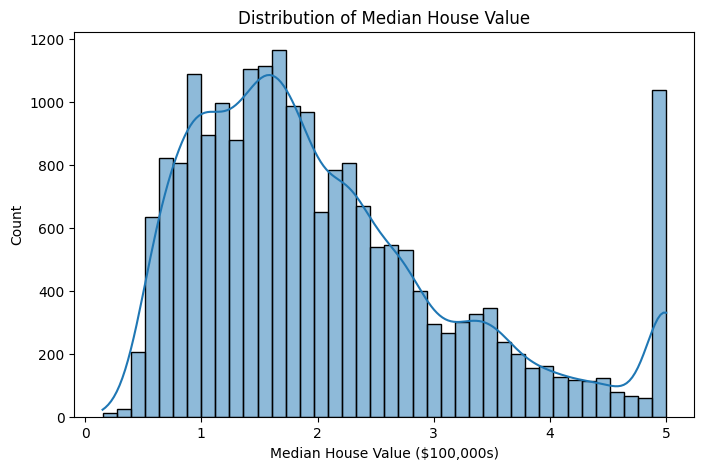

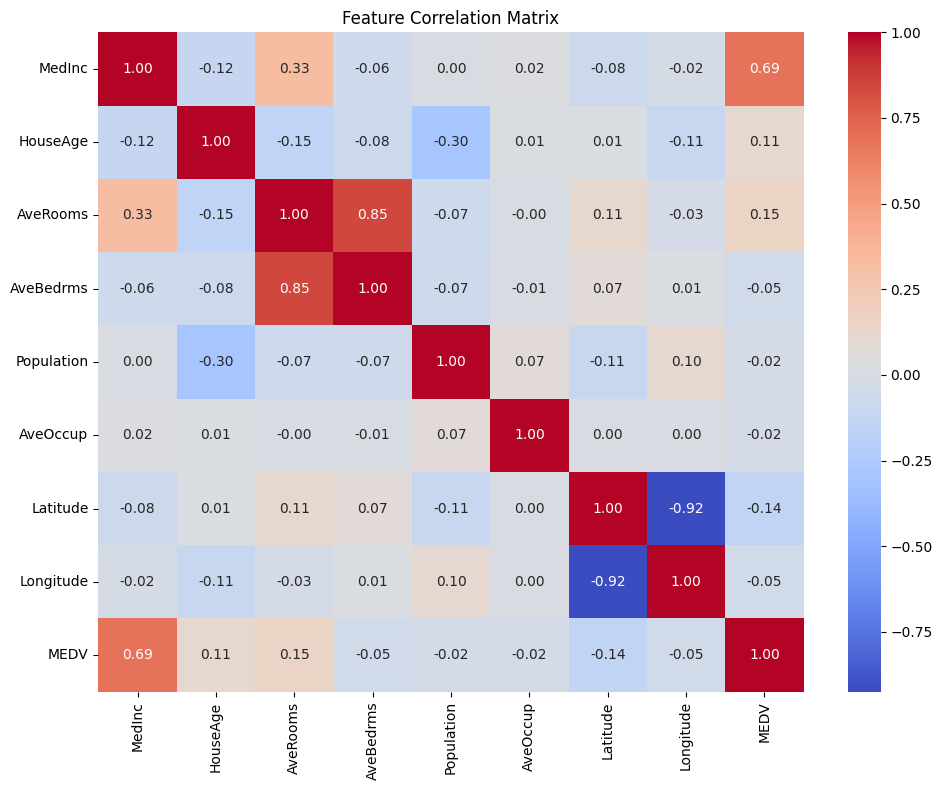

In [ ]:
#data analysis
df.describe()

plt.figure(figsize=(8,5))
sns.histplot(df["MEDV"], bins=40, kde=True)
plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value ($100,000s)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
#train/test split & scaling
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (16512, 8)
Test shape: (4128, 8)


**KNN Regression:**

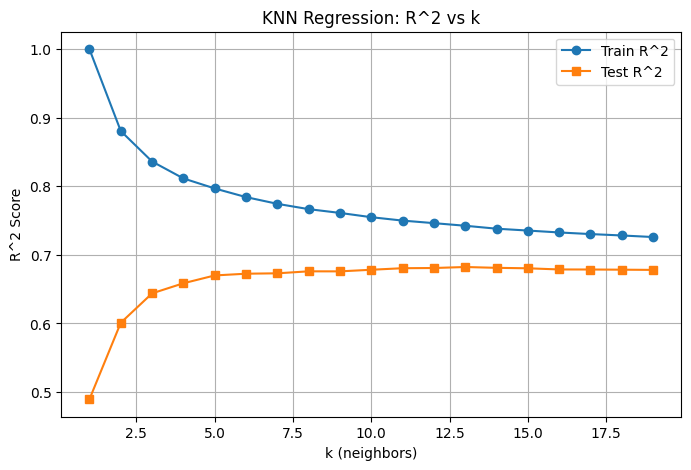

Optimal k: 13, Test R^2: 0.682


In [ ]:
k_values = range(1, 20)
train_scores_knn = []
test_scores_knn = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_scores_knn.append(r2_score(y_train, knn.predict(X_train_scaled)))
    test_scores_knn.append(r2_score(y_test, knn.predict(X_test_scaled)))

plt.figure(figsize=(8,5))
plt.plot(k_values, train_scores_knn, marker='o', label="Train R^2")
plt.plot(k_values, test_scores_knn, marker='s', label="Test R^2")
plt.title("KNN Regression: R^2 vs k")
plt.xlabel("k (neighbors)")
plt.ylabel("R^2 Score")
plt.legend()
plt.grid(True)
plt.show()

optimal_k = k_values[np.argmax(test_scores_knn)]
print(f"Optimal k: {optimal_k}, Test R^2: {max(test_scores_knn):.3f}")

**Linear Regression (Baseline):**

In [ ]:
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)

train_r2_ols = r2_score(y_train, ols.predict(X_train_scaled))
test_r2_ols = r2_score(y_test, ols.predict(X_test_scaled))

print(f"OLS Train R^2: {train_r2_ols:.3f}")
print(f"OLS Test R^2: {test_r2_ols:.3f}")

OLS Train R^2: 0.613
OLS Test R^2: 0.576


**Ridge Regression (L2 Regularization):**

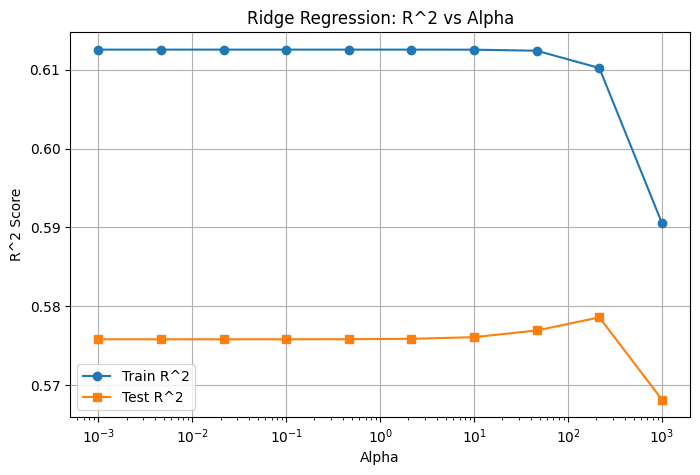

Optimal Ridge Alpha: 215.4435, Test R^2: 0.579


In [ ]:
alpha_values = np.logspace(-3, 3, 10)
ridge_train_scores = []
ridge_test_scores = []

for alpha in alpha_values:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    ridge_train_scores.append(r2_score(y_train, ridge.predict(X_train_scaled)))
    ridge_test_scores.append(r2_score(y_test, ridge.predict(X_test_scaled)))

plt.figure(figsize=(8,5))
plt.plot(alpha_values, ridge_train_scores, marker='o', label="Train R^2")
plt.plot(alpha_values, ridge_test_scores, marker='s', label="Test R^2")
plt.title("Ridge Regression: R^2 vs Alpha")
plt.xlabel("Alpha")
plt.ylabel("R^2 Score")
plt.xscale("log")
plt.legend()
plt.grid(True)
plt.show()

optimal_alpha_ridge = alpha_values[np.argmax(ridge_test_scores)]
print(f"Optimal Ridge Alpha: {optimal_alpha_ridge:.4f}, Test R^2: {max(ridge_test_scores):.3f}")

**Lasso Regression (L1 Regularization):**

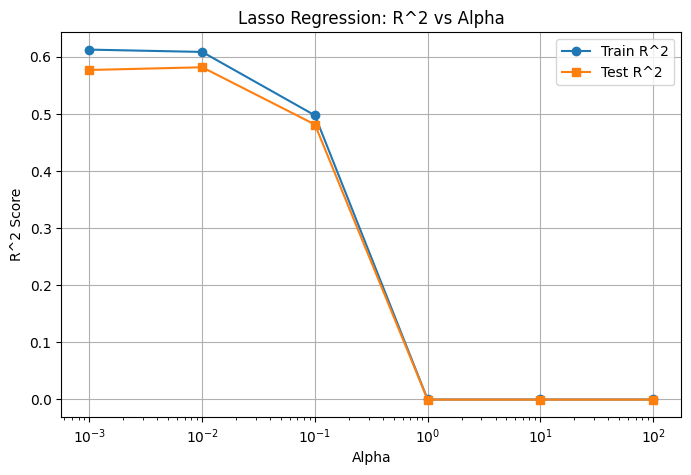

Optimal Lasso Alpha: 0.01, Test R^2: 0.582


In [ ]:
alpha_values_lasso = [0.001, 0.01, 0.1, 1, 10, 100]
lasso_train_scores = []
lasso_test_scores = []

for alpha in alpha_values_lasso:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    lasso_train_scores.append(r2_score(y_train, lasso.predict(X_train_scaled)))
    lasso_test_scores.append(r2_score(y_test, lasso.predict(X_test_scaled)))

plt.figure(figsize=(8,5))
plt.plot(alpha_values_lasso, lasso_train_scores, marker='o', label="Train R^2")
plt.plot(alpha_values_lasso, lasso_test_scores, marker='s', label="Test R^2")
plt.title("Lasso Regression: R^2 vs Alpha")
plt.xlabel("Alpha")
plt.ylabel("R^2 Score")
plt.xscale("log")
plt.legend()
plt.grid(True)
plt.show()

optimal_alpha_lasso = alpha_values_lasso[np.argmax(lasso_test_scores)]
print(f"Optimal Lasso Alpha: {optimal_alpha_lasso}, Test R^2: {max(lasso_test_scores):.3f}")

**Ridge vs. Lasso:**

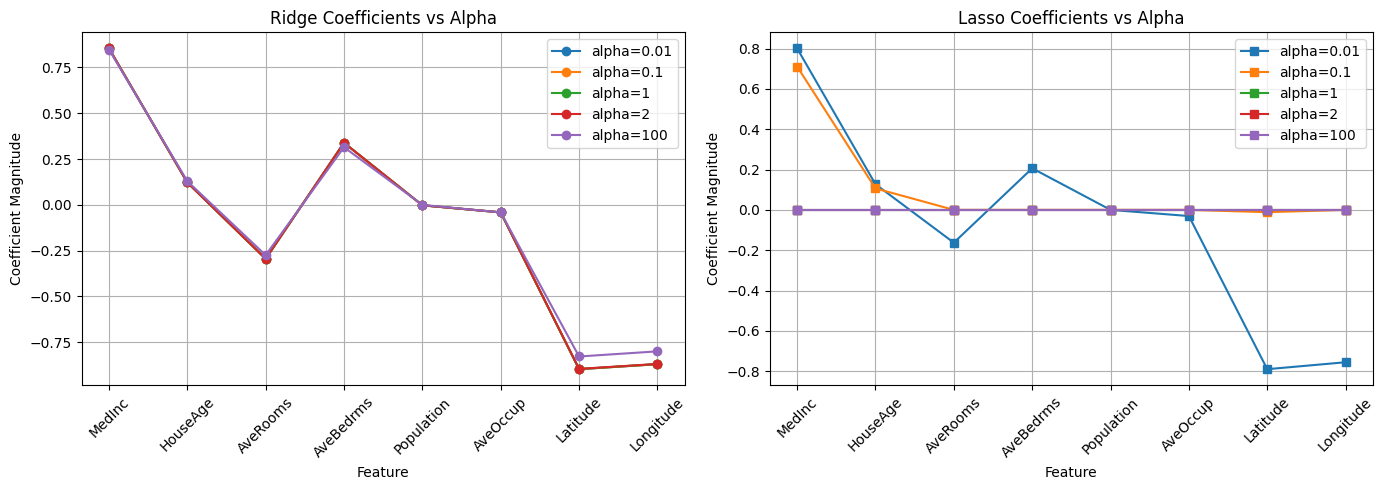

In [ ]:
feature_names = X_train.columns
alphas_to_plot = [0.01, 0.1, 1, 2, 100]

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
for alpha in alphas_to_plot:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    plt.plot(feature_names, ridge.coef_, marker='o', label=f'alpha={alpha}')
plt.title("Ridge Coefficients vs Alpha")
plt.xlabel("Feature")
plt.ylabel("Coefficient Magnitude")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
for alpha in alphas_to_plot:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    plt.plot(feature_names, lasso.coef_, marker='s', label=f'alpha={alpha}')
plt.title("Lasso Coefficients vs Alpha")
plt.xlabel("Feature")
plt.ylabel("Coefficient Magnitude")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Model Comparison:**

In [ ]:
summary = pd.DataFrame({
    "Model": ["KNN (best k)", "OLS", "Ridge (best alpha)", "Lasso (best alpha)"],
    "Test R^2": [
        max(test_scores_knn),
        test_r2_ols,
        max(ridge_test_scores),
        max(lasso_test_scores)
    ]
}).sort_values("Test R^2", ascending=False).reset_index(drop=True)

summary

,Model,Test R^2
0,KNN (best k),0.682321
1,Lasso (best alpha),0.581615
2,Ridge (best alpha),0.578569
3,OLS,0.575788


# **Conclusion:**

I compared four regression models to predict California housing prices: KNN, Linear Regression (OLS), Ridge, and Lasso

**KNN came out on top** (R² = 0.68), beating the three linear models, which all landed around R² = 0.58

Why does that make sense? Housing prices in California are heavily driven by *location*, and that relationship isn't linear. A house isn't just worth more because one feature (like income or room count) goes up steadily, it's more about which neighborhood it's in and what's nearby. Linear models (OLS, Ridge, Lasso) can only draw straight-line relationships between features and price, so they hit a ceiling. KNN, on the other hand, just looks at similar houses nearby and predicts based on them, which naturally picks up on those location-based clusters better

**Takeaway:** for this kind of geographically-driven data, a model that can "look at neighbors" outperforms models that assume everything moves in a straight line

**If I kept going:** I'd try a Random Forest or Gradient Boosting model next, since tree-based models are also good at capturing this kind of non-linear, location-driven pattern, and might beat KNN. I'd also add engineered features like rooms-per-household, which could help the linear models close the gap

